In [10]:
import torch
import operator

from typing import TypedDict, Annotated

from pydantic import BaseModel, Field

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    pipeline
)

from langchain_huggingface import (
    HuggingFacePipeline,
    ChatHuggingFace
)

from langchain_core.messages import (
    SystemMessage,
    HumanMessage
)

from langchain_core.output_parsers import (
    PydanticOutputParser
)

from langgraph.graph import (
    StateGraph,
    START,
    END
)

In [3]:
model_id = "Qwen/Qwen2.5-Coder-1.5B-Instruct"


tokenizer = AutoTokenizer.from_pretrained(
    model_id
)


model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=(
        torch.bfloat16
        if torch.cuda.is_available()
        else torch.float32
    ),
    device_map="auto"
)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the disk and cpu.


In [4]:
hf_pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=256,
    temperature=0.2,
    return_full_text=False
)

[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [5]:
llm = ChatHuggingFace(
    llm=HuggingFacePipeline(
        pipeline=hf_pipe
    )
)

In [6]:
generator_llm = llm
evaluator_llm = llm
optimizer_llm = llm

In [7]:
class AnswerEvaluation(BaseModel):

    score: int = Field(
        ...,
        ge=1,
        le=10,
        description="Quality score of the answer from 1 to 10."
    )

    feedback: str = Field(
        ...,
        description=(
            "Short feedback explaining what should be improved "
            "or stating that the answer is good."
        )
    )

In [11]:
evaluation_parser = PydanticOutputParser(
    pydantic_object=AnswerEvaluation
)

In [12]:
class AnswerState(TypedDict):

    question: str

    answer: str

    score: int

    feedback: str

    iteration: int

    max_iteration: int

    answer_history: Annotated[
        list[str],
        operator.add
    ]

    score_history: Annotated[
        list[int],
        operator.add
    ]

    feedback_history: Annotated[
        list[str],
        operator.add
    ]

In [13]:
def generate_answer(state: AnswerState):

    messages = [

        SystemMessage(
            content="""
You are a helpful assistant.

Answer the user's question clearly, accurately,
and concisely.

Use simple English and cover the important points.
"""
        ),

        HumanMessage(
            content=f"""
Question:

{state['question']}

Generate a clear and complete answer.
"""
        )
    ]

    response = generator_llm.invoke(
        messages
    ).content

    return {

        "answer": response,

        "answer_history": [
            response
        ]
    }

In [14]:
def evaluate_answer(state: AnswerState):

    messages = [

        SystemMessage(
            content=f"""
You are a strict answer evaluator.

Evaluate the answer based on:

1. Accuracy
2. Relevance
3. Completeness
4. Clarity
5. Missing important information

Give the answer a score from 1 to 10.

Scoring guideline:

1-4 = Poor answer
5-7 = Needs improvement
8-10 = Good answer

If important information is missing,
clearly explain what should be added.

If the answer is already good,
give short positive feedback such as:

"Good answer."

Return ONLY the required structured output.

{evaluation_parser.get_format_instructions()}
"""
        ),

        HumanMessage(
            content=f"""
Question:

{state['question']}


Answer:

{state['answer']}


Evaluate this answer.
"""
        )
    ]

    response = evaluator_llm.invoke(
        messages
    )

    result = evaluation_parser.parse(
        response.content
    )

    return {

        "score": result.score,

        "feedback": result.feedback,

        "score_history": [
            result.score
        ],

        "feedback_history": [
            result.feedback
        ]
    }

In [15]:
def improve_answer(state: AnswerState):

    messages = [

        SystemMessage(
            content="""
You improve answers using evaluator feedback.

Keep the useful information from the current answer.

Fix the weaknesses.

Add important missing information.

Make the answer clearer and more complete.

Return only the improved answer.
"""
        ),

        HumanMessage(
            content=f"""
Question:

{state['question']}


Current Answer:

{state['answer']}


Evaluator Feedback:

{state['feedback']}


Rewrite and improve the answer using the feedback.
"""
        )
    ]

    response = optimizer_llm.invoke(
        messages
    ).content

    iteration = (
        state["iteration"] + 1
    )

    return {

        "answer": response,

        "iteration": iteration,

        "answer_history": [
            response
        ]
    }

In [16]:
def route_evaluation(state: AnswerState):

    if state["score"] >= 8:

        return "approved"


    if state["iteration"] >= state["max_iteration"]:

        return "approved"


    return "needs_improvement"

In [17]:
graph = StateGraph(
    AnswerState
)

In [18]:
graph.add_node(
    "generate",
    generate_answer
)

graph.add_node(
    "evaluate",
    evaluate_answer
)
graph.add_node(
    "improve",
    improve_answer
)

In [20]:
graph.add_edge(
    START,
    "generate"
)

graph.add_edge(
    "generate",
    "evaluate"
)

graph.add_conditional_edges(

    "evaluate",

    route_evaluation,

    {

        "approved": END,

        "needs_improvement": "improve"

    }
)


graph.add_edge(
    "improve",
    "evaluate"
)



In [21]:
workflow = graph.compile()

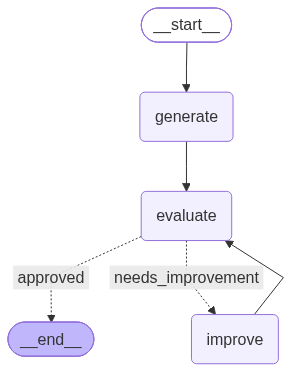

In [23]:
from IPython.display import (
    Image,
    display
)

display(
    Image(
        workflow
        .get_graph()
        .draw_mermaid_png()
    )
)

In [24]:
initial_state = {

    "question":
        "Explain the benefits of using electric vehicles.",

    "iteration": 1,

    "max_iteration": 5,

    "answer_history": [],

    "score_history": [],

    "feedback_history": []
}

In [25]:
result = workflow.invoke(
    initial_state
)

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [26]:
result 

{'question': 'Explain the benefits of using electric vehicles.',
 'answer': 'Electric vehicles (EVs) offer several significant benefits over traditional gasoline-powered cars. Here’s a detailed explanation:\n\n1. **Environmental Impact**: EVs produce zero tailpipe emissions, which means they significantly reduce air pollution and contribute to cleaner air for everyone. This is particularly important in urban areas where air quality is often poor.\n\n2. **Energy Efficiency**: Electric motors are more efficient than internal combustion engines. They convert electrical energy directly into motion without burning fuel, resulting in lower fuel consumption and fewer emissions.\n\n3. **Longer Range**: Many modern EVs can travel much farther on a single charge compared to gas-powered cars. This makes them ideal for long-distance trips or commuting.\n\n4. **Cost Savings**: While the initial cost of purchasing an EV can be higher than a gas car, the long-term savings can be substantial due to re

In [27]:
for i, answer in enumerate(
    result["answer_history"]
):

    iteration_number = i + 1

    print(
        f"\nIteration {iteration_number}"
    )

    print("-" * 50)


    if iteration_number == 1:

        print("\nAnswer generated\n")

    else:

        print("\nAnswer improved\n")


    print(answer)


    print(
        f"\nScore: "
        f"{result['score_history'][i]}"
    )


    print(
        f"\nFeedback: "
        f"{result['feedback_history'][i]}"
    )


Iteration 1
--------------------------------------------------

Answer generated

Electric vehicles (EVs) offer several significant benefits over traditional gasoline-powered cars. Here’s a detailed explanation:

1. **Environmental Impact**: EVs produce zero tailpipe emissions, which means they significantly reduce air pollution and contribute to cleaner air for everyone. This is particularly important in urban areas where air quality is often poor.

2. **Energy Efficiency**: Electric motors are more efficient than internal combustion engines. They convert electrical energy directly into motion without burning fuel, resulting in lower fuel consumption and fewer emissions.

3. **Longer Range**: Many modern EVs can travel much farther on a single charge compared to gas-powered cars. This makes them ideal for long-distance trips or commuting.

4. **Cost Savings**: While the initial cost of purchasing an EV can be higher than a gas car, the long-term savings can be substantial due to redu

In [28]:
print("\n\nFinal Answer")

print("-" * 50)

print(
    "\n" + result["answer"]
)



Final Answer
--------------------------------------------------

Electric vehicles (EVs) offer several significant benefits over traditional gasoline-powered cars. Here’s a detailed explanation:

1. **Environmental Impact**: EVs produce zero tailpipe emissions, which means they significantly reduce air pollution and contribute to cleaner air for everyone. This is particularly important in urban areas where air quality is often poor.

2. **Energy Efficiency**: Electric motors are more efficient than internal combustion engines. They convert electrical energy directly into motion without burning fuel, resulting in lower fuel consumption and fewer emissions.

3. **Longer Range**: Many modern EVs can travel much farther on a single charge compared to gas-powered cars. This makes them ideal for long-distance trips or commuting.

4. **Cost Savings**: While the initial cost of purchasing an EV can be higher than a gas car, the long-term savings can be substantial due to reduced fuel costs a